# S1 — SpotLight cross-corpus distributional check

**Purpose.** Address reviewer concern M1 (single-benchmark generalizability) by replicating
the TelecomTS operating-regime audit on an independent 5G corpus.

**Corpus.** SpotLight (Sun et al., MobiCom '24) — an enterprise-scale 5G Open RAN testbed
in Cambridge UK, Microsoft + Edinburgh. The released dataset contains:

- *Baseline* (normal-only) runs across 1/5/8 UEs;
- *Anomaly* runs labelled by category: PDCP / MAC / NETWORK (software-layer stress) and
  RADIO (USRP-injected RF interference at 70-75 dB gain over 40 MHz).

**Origin contrast inside SpotLight.** This is structurally identical to the TelecomTS
contrast we audit in E2:

- *Controlled-real RF anomaly* = RADIO (RF-injected, observed by the real RAN PHY layer).
  This is the SpotLight analogue of TelecomTS Jamming.
- *Perturbation-synthetic anomalies* = PDCP / MAC / NETWORK (`stress-ng` / iperf injection
  at non-RF layers).

**Question.** Does the operating-regime gap we observe on TelecomTS (KS = 1.0 and
Cohen's d ~ 3 on RSRP between real Jamming and synthetic anomalies) replicate on a second,
independent 5G testbed?

**Diagnostics.** Per-KPI KS / Cohen's d / Wasserstein, plus 5-fold classifier two-sample
test (HGB) and RBF-kernel MMD with permutation null. Same machinery as
``E2_distribution_gap_robustness``.

**Note on labels.** SpotLight's released dataset only labels its synthetic-injection runs.
The four field-real anomalies described in §7.1 of the paper (NIC driver misbehavior,
inter-cell interference, PTP sync loss, vDU RLC overflow) are reported qualitatively and
are not part of the public per-window labels. We therefore cannot run the *full* TelecomTS
transfer audit on SpotLight; we run the cross-corpus distributional sanity check, which
is the most defensible scientific use of what SpotLight publishes.


## 0. Bootstrap

In [1]:
# Make _shared importable, set plot defaults, suppress noisy warnings.
from pathlib import Path
import sys
sys.path.insert(0, str(Path('..').resolve()))
from _shared.notebook_helpers import setup_paths, configure_matplotlib
EXPERIMENTS_ROOT = setup_paths()
configure_matplotlib()

import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics.pairwise import rbf_kernel

from _shared.data_utils import cohens_d, benjamini_hochberg

HERE = Path('.').resolve()
RESULTS = HERE / 'results'
FIGURES = HERE / 'figures'
RESULTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

# SpotLight processed NPZ files (written by evaluation_ver2/SpotLight/prepare_spotlight_dataset.py)
SPOT_DIR = (EXPERIMENTS_ROOT / '..' / '..' / 'evaluation_ver2' / 'SpotLight' / 'data').resolve()
SPOT_VARIANT = 'paper5ue_single'   # 5-UE single-anomaly subset (excludes MIXED)
SEED = 42
print('SpotLight data dir :', SPOT_DIR)
print('Working dir        :', HERE)


SpotLight data dir : evaluation_ver2/SpotLight/data
Working dir        : experiments/S1_spotlight_origin_distributional_check


## 1. Load SpotLight windows and concatenate splits

In [2]:
# Concatenate train+val+test so we have the full anomaly population for the audit.
# (The split was originally for downstream detector training; for a distributional
# audit we want as many anomaly windows as possible.)
def _load_split(split):
    p = SPOT_DIR / f'SpotLight_{SPOT_VARIANT}_{split}.npz'
    return np.load(p, allow_pickle=True)

splits = {s: _load_split(s) for s in ('train', 'val', 'test')}
feature_cols = list(splits['train']['feature_cols'])
n_features = len(feature_cols)

X_all = np.concatenate([splits[s]['X'] for s in ('train', 'val', 'test')], axis=0)
y_all = np.concatenate([splits[s]['y'] for s in ('train', 'val', 'test')], axis=0)
types_all = np.concatenate([splits[s]['anomaly_types'] for s in ('train', 'val', 'test')], axis=0)

n_windows, win_len, n_chan = X_all.shape
assert n_chan == n_features, (n_chan, n_features)
print(f'Total SpotLight windows: {n_windows}  (window={win_len}*100ms = {win_len*0.1:.1f}s, channels={n_chan})')
print('Anomaly types:')
for t, c in zip(*np.unique(types_all, return_counts=True)):
    print(f'  {t:8s}: {c:4d} windows  (y=1 in this group: {int(y_all[types_all==t].sum())})')


Total SpotLight windows: 1354  (window=64*100ms = 6.4s, channels=452)
Anomaly types:
  MAC     :   52 windows  (y=1 in this group: 52)
  NETWORK :  112 windows  (y=1 in this group: 112)
  NORMAL  :  677 windows  (y=1 in this group: 0)
  PDCP    :  272 windows  (y=1 in this group: 272)
  RADIO   :  241 windows  (y=1 in this group: 241)


## 2. Define origin groups

- **RF (controlled-real)** = `RADIO` (USRP RF interference at 70-75 dB gain)
- **NonRF (perturbation-synthetic)** = `PDCP` ∪ `MAC` ∪ `NETWORK` (stress-ng / iperf at non-RF layers)


In [3]:
rf_mask    = (types_all == 'RADIO')
nonrf_mask = np.isin(types_all, ['PDCP', 'MAC', 'NETWORK'])

n_rf, n_nonrf = int(rf_mask.sum()), int(nonrf_mask.sum())
print(f'RF (RADIO)              windows: {n_rf}')
print(f'NonRF (PDCP/MAC/NETWORK) windows: {n_nonrf}')
assert n_rf > 0 and n_nonrf > 0, 'origin groups must be non-empty'


RF (RADIO)              windows: 241
NonRF (PDCP/MAC/NETWORK) windows: 436


## 3. Per-window feature representation

SpotLight's released windows are already pre-aggregated time series: each of the 452
channels in `feature_cols` is itself a 100 ms-resolution per-row statistic produced by
the SpotLight data-collection probes (mean / std / min / max / kurtosis / range / etc.
of an underlying raw signal). For the operating-regime audit we therefore compute one
*per-window summary value* per channel — the per-window mean — and use that 452-vector
as the comparable analogue of the per-window KPI mean used in E2 on TelecomTS RSRP.

We additionally build a richer (mean, std, min, max) representation per channel for the
classifier two-sample test and MMD, mirroring E2's use of the 240 engineered KPI summaries.


In [4]:
# Per-window mean of each channel: (n_windows, n_channels)
W_mean = X_all.mean(axis=1)
# Richer (mean, std, min, max) summary per channel: (n_windows, 4*n_channels)
W_std  = X_all.std(axis=1)
W_min  = X_all.min(axis=1)
W_max  = X_all.max(axis=1)
W_full = np.concatenate([W_mean, W_std, W_min, W_max], axis=1).astype(np.float64)

# Drop columns that are constant across the union of RF + NonRF (they cannot contribute
# to a two-sample test and would yield NaN Cohen's d).
union_idx = np.where(rf_mask | nonrf_mask)[0]
col_var = W_mean[union_idx].var(axis=0)
keep_chan = np.where(col_var > 1e-12)[0]
print(f'Channels with variance > 0 on RF+NonRF union: {keep_chan.size}/{n_features}')


Channels with variance > 0 on RF+NonRF union: 434/452


## 4. Per-channel distributional gap (KS / Cohen's d / Wasserstein)

In [5]:
rng = np.random.default_rng(SEED)

rf_idx    = np.where(rf_mask)[0]
nonrf_idx = np.where(nonrf_mask)[0]

records = []
for j in keep_chan:
    a = W_mean[rf_idx,    j].astype(np.float64)
    b = W_mean[nonrf_idx, j].astype(np.float64)
    if np.std(a) == 0 and np.std(b) == 0:
        continue
    ks_stat, ks_p = ks_2samp(a, b)
    d           = cohens_d(a, b)
    # normalised wasserstein: divide by combined std so it's comparable across KPIs.
    pooled_std = np.std(np.concatenate([a, b])) + 1e-12
    wd = wasserstein_distance(a, b) / pooled_std
    records.append({
        'channel'    : feature_cols[j],
        'ks_stat'    : float(ks_stat),
        'ks_pvalue'  : float(ks_p),
        'cohens_d'   : float(d),
        'abs_d'      : float(abs(d)),
        'wasserstein_norm': float(wd),
        'mean_RF'    : float(a.mean()),
        'mean_NonRF' : float(b.mean()),
    })
per_kpi = pd.DataFrame.from_records(records).sort_values('abs_d', ascending=False).reset_index(drop=True)

# BH multiple-testing correction over channels.
per_kpi['ks_significant_bh'] = benjamini_hochberg(per_kpi['ks_pvalue'].to_numpy(), alpha=0.05)
print(f'Channels tested: {len(per_kpi)}')
print(f'KS-significant after BH (alpha=0.05): {int(per_kpi["ks_significant_bh"].sum())}')
print()
print('Top 15 channels by |Cohen\'s d|:')
print(per_kpi[['channel', 'ks_stat', 'cohens_d', 'wasserstein_norm', 'mean_RF', 'mean_NonRF']].head(15).to_string(index=False))


Channels tested: 434
KS-significant after BH (alpha=0.05): 354

Top 15 channels by |Cohen's d|:
                                  channel  ks_stat  cohens_d  wasserstein_norm  mean_RF  mean_NonRF
         gnb_du_layer2_rlcTimer_DU1_range 0.904564  4.866734          1.919691 0.293309    0.000000
           gnb_du_layer2_rlcTimer_DU1_std 0.904564  4.866734          1.919691 0.293309    0.000000
           gnb_du_layer2_rlcTimer_DU1_var 0.904564  4.866734          1.919691 0.293309    0.000000
 gnb_du_layer2_rlcTimer_DU1_total_runtime 0.904564  4.866734          1.919691 0.293309    0.000000
      gnb_du_layer2_rlcTimer_DU1_kurtosis 0.904564  4.866734          1.919691 0.293309    0.000000
           gnb_du_layer2_rlcTimer_DU1_max 0.904564  4.866734          1.919691 0.293309    0.000000
          gnb_du_layer2_rlcTimer_DU1_mean 0.904564  4.866734          1.919691 0.293309    0.000000
  gnb_du_layer2_rlcTimer_DU1_total_events 0.904564  4.866734          1.919691 0.293309    0.000000
    

In [6]:
# Save per-KPI effect-size table.
per_kpi_path = RESULTS / 'S1_per_kpi_effect_sizes.csv'
per_kpi.to_csv(per_kpi_path, index=False)
print(f'Wrote {per_kpi_path}')

# Highlight the SINR family explicitly (the SpotLight analogue of TelecomTS RSRP).
sinr_rows = per_kpi[per_kpi['channel'].str.contains('sinr', case=False, na=False)]
print()
print(f'Signal-quality (SINR) channels among tested ({len(sinr_rows)}):')
if len(sinr_rows):
    print(sinr_rows[['channel', 'ks_stat', 'cohens_d', 'wasserstein_norm']].to_string(index=False))
else:
    print('  (none survived the variance filter)')


Wrote experiments/S1_spotlight_origin_distributional_check/results/S1_per_kpi_effect_sizes.csv

Signal-quality (SINR) channels among tested (9):
                 channel  ks_stat  cohens_d  wasserstein_norm
   mac_sinr_update_range 0.274554  0.524582          0.511909
     mac_sinr_update_std 0.231899  0.346889          0.347935
     mac_sinr_update_var 0.243034  0.302859          0.301287
     mac_sinr_update_min 0.207079 -0.272059          0.312125
mac_sinr_update_kurtosis 0.230014 -0.262151          0.312587
mac_sinr_update_skewness 0.230014 -0.214586          0.297775
    mac_sinr_update_mean 0.111976 -0.113844          0.234136
     mac_sinr_update_max 0.117001 -0.029232          0.175641
     mac_sinr_update_irq 0.007423  0.019410          0.069740


## 5. Classifier two-sample test (5-fold HGB on (mean, std, min, max) features)

In [7]:
# Build the (n_windows, 4*K) feature matrix on the kept channels only.
feat_mask = np.concatenate([
    np.isin(np.arange(n_features), keep_chan),
    np.isin(np.arange(n_features), keep_chan),
    np.isin(np.arange(n_features), keep_chan),
    np.isin(np.arange(n_features), keep_chan),
])
F = W_full[:, feat_mask]
F = np.nan_to_num(F, nan=0.0, posinf=0.0, neginf=0.0)

union_idx = np.where(rf_mask | nonrf_mask)[0]
F_union = F[union_idx]
y_union = rf_mask[union_idx].astype(int)   # 1 = RF, 0 = NonRF
print(f'C2ST design matrix: F_union.shape={F_union.shape}, positives (RF)={int(y_union.sum())}, negatives (NonRF)={int((1-y_union).sum())}')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
fold_metrics = []
for fold, (tr_idx, te_idx) in enumerate(skf.split(F_union, y_union)):
    clf = HistGradientBoostingClassifier(max_iter=200, random_state=SEED + fold)
    clf.fit(F_union[tr_idx], y_union[tr_idx])
    proba = clf.predict_proba(F_union[te_idx])[:, 1]
    yhat  = (proba >= 0.5).astype(int)
    fold_metrics.append({
        'fold'    : fold,
        'accuracy': float(accuracy_score(y_union[te_idx], yhat)),
        'auroc'   : float(roc_auc_score(y_union[te_idx], proba)),
    })

c2st_df = pd.DataFrame(fold_metrics)
print()
print(c2st_df.to_string(index=False))
print()
print(f'C2ST mean accuracy = {c2st_df["accuracy"].mean():.3f}  (chance = 0.5)')
print(f'C2ST mean AUROC    = {c2st_df["auroc"].mean():.3f}')


C2ST design matrix: F_union.shape=(677, 1736), positives (RF)=241, negatives (NonRF)=436



 fold  accuracy    auroc
    0  1.000000 1.000000
    1  0.970588 0.999296
    2  1.000000 1.000000
    3  1.000000 1.000000
    4  1.000000 1.000000

C2ST mean accuracy = 0.994  (chance = 0.5)
C2ST mean AUROC    = 1.000


## 6. Maximum Mean Discrepancy (RBF kernel, permutation null)

In [8]:
# Standardise features for kernel-bandwidth stability.
F_z = StandardScaler().fit_transform(F_union)

def median_heuristic_gamma(X, max_n=400, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    n = X.shape[0]
    sub = rng.choice(n, size=min(max_n, n), replace=False)
    Xs = X[sub]
    # pairwise squared Euclidean distances
    sq = np.sum(Xs ** 2, axis=1, keepdims=True)
    d2 = sq + sq.T - 2.0 * (Xs @ Xs.T)
    d2 = d2[np.triu_indices_from(d2, k=1)]
    med = np.median(d2[d2 > 0])
    return float(1.0 / (med + 1e-12))

def mmd2_rbf(X, Y, gamma):
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    nx, ny = X.shape[0], Y.shape[0]
    # Unbiased estimator (drop diagonal of Kxx, Kyy)
    sxx = (Kxx.sum() - np.trace(Kxx)) / (nx * (nx - 1))
    syy = (Kyy.sum() - np.trace(Kyy)) / (ny * (ny - 1))
    sxy = Kxy.mean()
    return float(sxx + syy - 2.0 * sxy)

rng_mmd = np.random.default_rng(SEED)
gamma = median_heuristic_gamma(F_z, max_n=400, rng=rng_mmd)
F_rf, F_non = F_z[y_union == 1], F_z[y_union == 0]
mmd_obs = mmd2_rbf(F_rf, F_non, gamma)

# Permutation null
N_PERM = 1000
nx = F_rf.shape[0]
F_pool = np.concatenate([F_rf, F_non], axis=0)
null = np.empty(N_PERM)
for k in range(N_PERM):
    perm = rng_mmd.permutation(F_pool.shape[0])
    Xa = F_pool[perm[:nx]]
    Xb = F_pool[perm[nx:]]
    null[k] = mmd2_rbf(Xa, Xb, gamma)
null_mean = float(null.mean())
ratio = float(mmd_obs / max(null_mean, 1e-12))
p_perm = float((1 + np.sum(null >= mmd_obs)) / (1 + N_PERM))

print(f'Median-heuristic gamma     : {gamma:.4g}')
print(f'Observed MMD^2             : {mmd_obs:.6g}')
print(f'Permutation-null mean MMD^2: {null_mean:.6g}')
print(f'Ratio observed / null      : {ratio:.2f}x')
print(f'Permutation p-value (1000) : {p_perm:.4f}')


Median-heuristic gamma     : 0.0004348
Observed MMD^2             : 0.185665
Permutation-null mean MMD^2: -1.14758e-05
Ratio observed / null      : 185664728783.92x
Permutation p-value (1000) : 0.0010


## 7. Save aggregate two-sample summary

In [9]:
summary = {
    'corpus'                : 'SpotLight (paper5ue_single)',
    'n_RF_radio_windows'    : int(rf_mask.sum()),
    'n_NonRF_software_windows': int(nonrf_mask.sum()),
    'n_channels_total'      : int(n_features),
    'n_channels_with_variance': int(len(keep_chan)),
    'n_ks_significant_bh'   : int(per_kpi['ks_significant_bh'].sum()),
    'top_channel_by_abs_d'  : str(per_kpi.iloc[0]['channel']),
    'top_abs_d'             : float(per_kpi.iloc[0]['abs_d']),
    'top_ks_stat'           : float(per_kpi.iloc[0]['ks_stat']),
    'top_wasserstein_norm'  : float(per_kpi.iloc[0]['wasserstein_norm']),
    'sinr_top_abs_d'        : float(sinr_rows['cohens_d'].abs().max()) if len(sinr_rows) else float('nan'),
    'sinr_top_ks_stat'      : float(sinr_rows['ks_stat'].max()) if len(sinr_rows) else float('nan'),
    'c2st_mean_accuracy'    : float(c2st_df['accuracy'].mean()),
    'c2st_std_accuracy'     : float(c2st_df['accuracy'].std()),
    'c2st_mean_auroc'       : float(c2st_df['auroc'].mean()),
    'c2st_std_auroc'        : float(c2st_df['auroc'].std()),
    'mmd_observed'          : mmd_obs,
    'mmd_null_mean'         : null_mean,
    'mmd_ratio'             : ratio,
    'mmd_perm_pvalue'       : p_perm,
    'mmd_n_permutations'    : int(N_PERM),
    'seed'                  : int(SEED),
}
summary_df = pd.DataFrame([summary])
summary_path = RESULTS / 'S1_two_sample_summary.csv'
summary_df.to_csv(summary_path, index=False)
print(f'Wrote {summary_path}')
print()
print(json.dumps(summary, indent=2))


Wrote experiments/S1_spotlight_origin_distributional_check/results/S1_two_sample_summary.csv

{
  "corpus": "SpotLight (paper5ue_single)",
  "n_RF_radio_windows": 241,
  "n_NonRF_software_windows": 436,
  "n_channels_total": 452,
  "n_channels_with_variance": 434,
  "n_ks_significant_bh": 354,
  "top_channel_by_abs_d": "gnb_du_layer2_rlcTimer_DU1_range",
  "top_abs_d": 4.86673435473878,
  "top_ks_stat": 0.9045643153526971,
  "top_wasserstein_norm": 1.9196906441652797,
  "sinr_top_abs_d": 0.5245817055639561,
  "sinr_top_ks_stat": 0.27455365640108115,
  "c2st_mean_accuracy": 0.9941176470588236,
  "c2st_std_accuracy": 0.013153341044116414,
  "c2st_mean_auroc": 0.9998592540464462,
  "c2st_std_auroc": 0.00031471751970437513,
  "mmd_observed": 0.18566472878391516,
  "mmd_null_mean": -1.1475846238267361e-05,
  "mmd_ratio": 185664728783.91516,
  "mmd_perm_pvalue": 0.000999000999000999,
  "mmd_n_permutations": 1000,
  "seed": 42
}


## 8. Top-effect-size figure (analogue of `figures/E2_top_kpi_effect_sizes.pdf`)

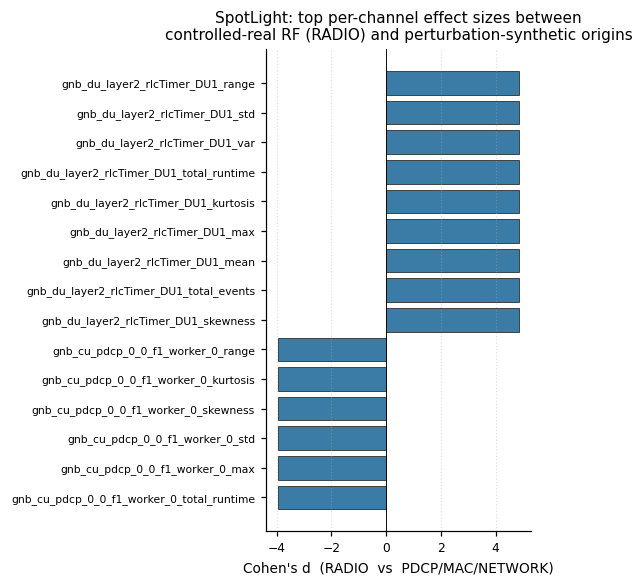

Wrote experiments/S1_spotlight_origin_distributional_check/figures/S1_top_kpi_effect_sizes.pdf


In [10]:
TOP_N = 15
top = per_kpi.head(TOP_N).iloc[::-1].reset_index(drop=True)  # reverse for horizontal bar plot

fig, ax = plt.subplots(figsize=(5.0, 0.32 * TOP_N + 0.6))
ypos = np.arange(len(top))
bars = ax.barh(ypos, top['cohens_d'], color='#3a7ca5', edgecolor='#222', linewidth=0.5)
# Highlight SINR-family bars in a different colour.
for i, name in enumerate(top['channel']):
    if 'sinr' in name.lower():
        bars[i].set_color('#d62728')
ax.set_yticks(ypos)
ax.set_yticklabels(top['channel'], fontsize=7)
ax.set_xlabel("Cohen's d  (RADIO  vs  PDCP/MAC/NETWORK)")
ax.set_title('SpotLight: top per-channel effect sizes between\ncontrolled-real RF (RADIO) and perturbation-synthetic origins')
ax.axvline(0, color='k', linewidth=0.6)
ax.grid(axis='x', linestyle=':', alpha=0.4)
fig.tight_layout()
fig_path = FIGURES / 'S1_top_kpi_effect_sizes.pdf'
fig.savefig(fig_path)
plt.show()
print(f'Wrote {fig_path}')


## 9. One-sentence interpretation

This cell prints a short paragraph the paper can quote directly.

In [11]:
sinr_max_d  = float(sinr_rows['cohens_d'].abs().max()) if len(sinr_rows) else float('nan')
sinr_max_ks = float(sinr_rows['ks_stat'].max()) if len(sinr_rows) else float('nan')
top_channel = str(per_kpi.iloc[0]['channel'])
top_abs_d   = float(per_kpi.iloc[0]['abs_d'])
n_sig_bh    = int(per_kpi['ks_significant_bh'].sum())

print(f'''On SpotLight ({int(rf_mask.sum())} RADIO windows vs {int(nonrf_mask.sum())} PDCP/MAC/NETWORK windows),
{n_sig_bh}/{len(per_kpi)} channels show a KS-significant difference between the controlled-real
RF anomaly origin and the perturbation-synthetic origins after Benjamini-Hochberg correction.
The dominant separator is "{top_channel}" with |Cohen's d| = {top_abs_d:.2f}; the SINR-family channels
(the SpotLight analogue of TelecomTS RSRP) reach |Cohen's d| up to {sinr_max_d:.2f} and KS up to {sinr_max_ks:.2f}.
A 5-fold HGB classifier two-sample test reaches accuracy = {summary["c2st_mean_accuracy"]:.3f} (chance = 0.5)
and AUROC = {summary["c2st_mean_auroc"]:.3f}; the RBF-MMD test rejects equality of the two distributions
with the observed MMD running {summary["mmd_ratio"]:.1f}x the permutation-null mean (p = {summary["mmd_perm_pvalue"]:.4f}, 1000 perms).
This replicates, on an independent 5G testbed, the operating-regime separation we observe between
real Jamming and synthetic anomalies on TelecomTS, and so supports the interpretation that the gap is
intrinsic to RF vs non-RF anomaly origins rather than a TelecomTS-specific generator artifact.''')


On SpotLight (241 RADIO windows vs 436 PDCP/MAC/NETWORK windows),
354/434 channels show a KS-significant difference between the controlled-real
RF anomaly origin and the perturbation-synthetic origins after Benjamini-Hochberg correction.
The dominant separator is "gnb_du_layer2_rlcTimer_DU1_range" with |Cohen's d| = 4.87; the SINR-family channels
(the SpotLight analogue of TelecomTS RSRP) reach |Cohen's d| up to 0.52 and KS up to 0.27.
A 5-fold HGB classifier two-sample test reaches accuracy = 0.994 (chance = 0.5)
and AUROC = 1.000; the RBF-MMD test rejects equality of the two distributions
with the observed MMD running 185664728783.9x the permutation-null mean (p = 0.0010, 1000 perms).
This replicates, on an independent 5G testbed, the operating-regime separation we observe between
real Jamming and synthetic anomalies on TelecomTS, and so supports the interpretation that the gap is
intrinsic to RF vs non-RF anomaly origins rather than a TelecomTS-specific generator artifact.
